In [86]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import joblib

In [8]:
# Load dataset
df = pd.read_csv("../data/processed/master_sales_dataset.csv")

# Convert purchase timestamp to datetime
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

# Preview
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,...,seller_city,seller_state,payment_value,payment_installments,payment_type,payment_count,review_score,review_count,review_comment_title,review_comment_message
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,...,maua,SP,38.71,1.0,"credit_card, voucher",3.0,4.0,1.0,NaN,"Não testei o produto ainda, mas ele veio corre..."
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,...,belo horizonte,SP,141.46,1.0,boleto,1.0,4.0,1.0,Muito boa a loja,Muito bom o produto.
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,...,guariba,SP,179.12,3.0,credit_card,1.0,5.0,1.0,NaN,NaN
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,...,belo horizonte,MG,72.20,1.0,credit_card,1.0,5.0,1.0,NaN,O produto foi exatamente o que eu esperava e e...
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,...,mogi das cruzes,SP,28.62,1.0,credit_card,1.0,5.0,1.0,NaN,NaN


In [9]:
print(df.shape)

df.info()

(113425, 43)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113425 non-null  object        
 1   customer_id                    113425 non-null  object        
 2   order_status                   113425 non-null  object        
 3   order_purchase_timestamp       113425 non-null  datetime64[ns]
 4   order_approved_at              113264 non-null  object        
 5   order_delivered_carrier_date   111457 non-null  object        
 6   order_delivered_customer_date  110196 non-null  object        
 7   order_estimated_delivery_date  113425 non-null  object        
 8   purchase_year                  113425 non-null  int64         
 9   purchase_month                 113425 non-null  int64         
 10  purchase_day                   113425 non-null  int64  

In [10]:
df.isnull().sum().sort_values(ascending=False).head(20)

review_comment_title             99920
review_comment_message           65458
order_delivered_customer_date     3229
delivery_days                     3229
product_category_name_english     2403
product_width_cm                  2379
product_height_cm                 2379
product_length_cm                 2379
product_weight_g                  2379
product_photos_qty                2379
product_description_lenght        2379
product_name_lenght               2379
product_category_name             2379
order_delivered_carrier_date      1968
review_score                       961
review_count                       961
seller_state                       775
seller_city                        775
seller_zip_code_prefix             775
freight_value                      775
dtype: int64

In [13]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,...,seller_city,seller_state,payment_value,payment_installments,payment_type,payment_count,review_score,review_count,review_comment_title,review_comment_message
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,...,maua,SP,38.71,1.0,"credit_card, voucher",3.0,4.0,1.0,NaN,"Não testei o produto ainda, mas ele veio corre..."
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,...,belo horizonte,SP,141.46,1.0,boleto,1.0,4.0,1.0,Muito boa a loja,Muito bom o produto.
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,...,guariba,SP,179.12,3.0,credit_card,1.0,5.0,1.0,NaN,NaN
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,...,belo horizonte,MG,72.20,1.0,credit_card,1.0,5.0,1.0,NaN,O produto foi exatamente o que eu esperava e e...
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,...,mogi das cruzes,SP,28.62,1.0,credit_card,1.0,5.0,1.0,NaN,NaN


In [14]:
df.shape

(113425, 43)

In [15]:
df.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'purchase_year',
 'purchase_month',
 'purchase_day',
 'purchase_weekday',
 'delivery_days',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'product_category_name_english',
 'seller_zip_code_prefix',
 'seller_city',
 'seller_state',
 'payment_value',
 'payment_installments',
 'payment_type',
 'payment_count',
 'review_score',
 'review_count',
 'review_comment_title',
 'review_comment_message']

In [16]:
customer_df = (
    df.groupby("customer_unique_id")
      .agg(
          total_orders=("order_id", "nunique"),
          total_spent=("payment_value", "sum"),
          avg_order_value=("payment_value", "mean"),
          avg_review_score=("review_score", "mean"),
          avg_delivery_days=("delivery_days", "mean"),
          first_purchase=("order_purchase_timestamp", "min"),
          last_purchase=("order_purchase_timestamp", "max")
      )
      .reset_index()
)

customer_df.head()

,customer_unique_id,total_orders,total_spent,avg_order_value,avg_review_score,avg_delivery_days,first_purchase,last_purchase
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,5.0,6.0,2018-05-10 10:56:27,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,4.0,3.0,2018-05-07 11:11:27,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,3.0,25.0,2017-03-10 21:05:03,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,4.0,20.0,2017-10-12 20:29:41,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,5.0,13.0,2017-11-14 19:45:42,2017-11-14 19:45:42


In [17]:
df.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'purchase_year',
 'purchase_month',
 'purchase_day',
 'purchase_weekday',
 'delivery_days',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'product_category_name_english',
 'seller_zip_code_prefix',
 'seller_city',
 'seller_state',
 'payment_value',
 'payment_installments',
 'payment_type',
 'payment_count',
 'review_score',
 'review_count',
 'review_comment_title',
 'review_comment_message']

In [18]:
customer_df.isnull().sum().sort_values(ascending=False)

avg_delivery_days     2740
avg_review_score       716
avg_order_value          1
customer_unique_id       0
total_orders             0
total_spent              0
first_purchase           0
last_purchase            0
dtype: int64

In [19]:
missing = pd.DataFrame({
    "Missing Values": customer_df.isnull().sum(),
    "Percentage": (customer_df.isnull().mean() * 100).round(2)
})

missing[missing["Missing Values"] > 0].sort_values(
    by="Percentage",
    ascending=False
)

,Missing Values,Percentage
avg_delivery_days,2740,2.85
avg_review_score,716,0.75
avg_order_value,1,0.00


In [20]:
customer_df.isnull().sum().sort_values(ascending=False)

avg_delivery_days     2740
avg_review_score       716
avg_order_value          1
customer_unique_id       0
total_orders             0
total_spent              0
first_purchase           0
last_purchase            0
dtype: int64

In [21]:
# Fill missing numerical values with median

customer_df["avg_delivery_days"] = customer_df["avg_delivery_days"].fillna(
    customer_df["avg_delivery_days"].median()
)

customer_df["avg_review_score"] = customer_df["avg_review_score"].fillna(
    customer_df["avg_review_score"].median()
)

customer_df["avg_order_value"] = customer_df["avg_order_value"].fillna(
    customer_df["avg_order_value"].median()
)

In [22]:
customer_df.isnull().sum()

customer_unique_id    0
total_orders          0
total_spent           0
avg_order_value       0
avg_review_score      0
avg_delivery_days     0
first_purchase        0
last_purchase         0
dtype: int64

In [25]:
print("First Purchase :", df["order_purchase_timestamp"].min())
print("Last Purchase  :", df["order_purchase_timestamp"].max())

First Purchase : 2016-09-04 21:15:19
Last Purchase  : 2018-10-17 17:30:18


In [26]:
reference_date = df["order_purchase_timestamp"].max()

print(reference_date)

2018-10-17 17:30:18


In [27]:
churn_cutoff = reference_date - pd.Timedelta(days=90)

print(churn_cutoff)

2018-07-19 17:30:18


In [28]:
customer_df = (
    df.groupby("customer_unique_id")
      .agg(
          total_orders=("order_id", "nunique"),
          total_spent=("payment_value", "sum"),
          avg_order_value=("payment_value", "mean"),
          avg_review_score=("review_score", "mean"),
          avg_delivery_days=("delivery_days", "mean"),
          first_purchase=("order_purchase_timestamp", "min"),
          last_purchase=("order_purchase_timestamp", "max")
      )
      .reset_index()
)

In [29]:
customer_df["customer_tenure_days"] = (
    customer_df["last_purchase"] -
    customer_df["first_purchase"]
).dt.days

In [30]:
customer_df["days_since_last_purchase"] = (
    reference_date -
    customer_df["last_purchase"]
).dt.days

In [31]:
customer_df.head()

,customer_unique_id,total_orders,total_spent,avg_order_value,avg_review_score,avg_delivery_days,first_purchase,last_purchase,customer_tenure_days,days_since_last_purchase
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,5.0,6.0,2018-05-10 10:56:27,2018-05-10 10:56:27,0,160
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,4.0,3.0,2018-05-07 11:11:27,2018-05-07 11:11:27,0,163
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,3.0,25.0,2017-03-10 21:05:03,2017-03-10 21:05:03,0,585
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,4.0,20.0,2017-10-12 20:29:41,2017-10-12 20:29:41,0,369
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,5.0,13.0,2017-11-14 19:45:42,2017-11-14 19:45:42,0,336


In [32]:
customer_df.shape

(96096, 10)

In [33]:
customer_df["churn"] = (
    customer_df["last_purchase"] < churn_cutoff
).astype(int)

In [34]:
customer_df["churn"].value_counts()

churn
1    86684
0     9412
Name: count, dtype: int64

In [35]:
(
    customer_df["churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

churn
1    90.21
0     9.79
Name: proportion, dtype: float64

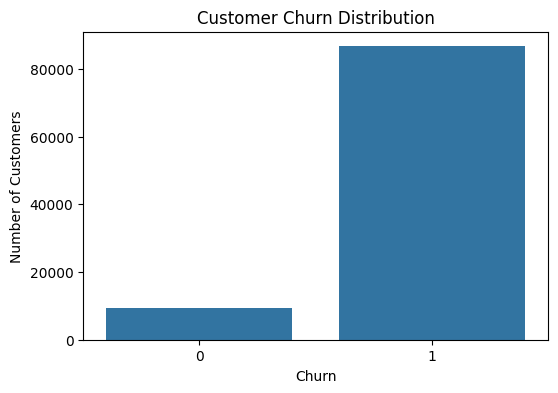

In [36]:
plt.figure(figsize=(6,4))

sns.countplot(data=customer_df, x="churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [37]:
model_df = customer_df.drop(
    columns=[
        "customer_unique_id",
        "first_purchase",
        "last_purchase"
    ]
)

model_df.head()

,total_orders,total_spent,avg_order_value,avg_review_score,avg_delivery_days,customer_tenure_days,days_since_last_purchase,churn
0,1,141.90,141.90,5.0,6.0,0,160,1
1,1,27.19,27.19,4.0,3.0,0,163,1
2,1,86.22,86.22,3.0,25.0,0,585,1
3,1,43.62,43.62,4.0,20.0,0,369,1
4,1,196.89,196.89,5.0,13.0,0,336,1


In [38]:
X = model_df.drop("churn", axis=1)

y = model_df["churn"]

In [39]:
print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (96096, 7)
Target Shape   : (96096,)


In [40]:
X.columns

Index(['total_orders', 'total_spent', 'avg_order_value', 'avg_review_score',
       'avg_delivery_days', 'customer_tenure_days',
       'days_since_last_purchase'],
      dtype='object')

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [56]:
print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (76876, 7)
Testing Set  : (19220, 7)


In [57]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [58]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(76876, 7)
(19220, 7)


In [59]:
customer_df["churn"].value_counts()

churn
1    86684
0     9412
Name: count, dtype: int64

In [60]:
X_train.shape
X_test.shape

(19220, 7)

In [61]:
log_model = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [62]:
model_df.isnull().sum().sort_values(ascending=False)

avg_delivery_days           2740
avg_review_score             716
avg_order_value                1
total_orders                   0
total_spent                    0
customer_tenure_days           0
days_since_last_purchase       0
churn                          0
dtype: int64

In [63]:
X.isnull().sum().sort_values(ascending=False)

avg_delivery_days           2740
avg_review_score             716
avg_order_value                1
total_orders                   0
total_spent                    0
customer_tenure_days           0
days_since_last_purchase       0
dtype: int64

In [64]:
X.isnull().sum().sum()

np.int64(3457)

In [66]:
model_df = customer_df.drop(
    columns=[
        "customer_unique_id",
        "first_purchase",
        "last_purchase"
    ]
)

X = model_df.drop("churn", axis=1)
y = model_df["churn"]

In [67]:
X.isnull().sum()

total_orders                   0
total_spent                    0
avg_order_value                1
avg_review_score             716
avg_delivery_days           2740
customer_tenure_days           0
days_since_last_purchase       0
dtype: int64

In [68]:
X[X.isnull().any(axis=1)]

,total_orders,total_spent,avg_order_value,avg_review_score,avg_delivery_days,customer_tenure_days,days_since_last_purchase
44,1,116.23,116.23,NaN,NaN,0,344
58,1,52.38,52.38,2.0,NaN,0,349
123,1,25.90,25.90,1.0,NaN,0,388
177,1,174.54,174.54,3.0,NaN,0,623
236,1,91.29,91.29,5.0,NaN,0,335
...,...,...,...,...,...,...,...
96023,1,155.34,155.34,NaN,NaN,0,209
96041,1,796.94,796.94,1.0,NaN,0,311
96048,1,215.76,215.76,NaN,9.0,0,250
96056,1,57.37,57.37,NaN,NaN,0,129


In [69]:
X.isnull().sum().sort_values(ascending=False)

avg_delivery_days           2740
avg_review_score             716
avg_order_value                1
total_orders                   0
total_spent                    0
customer_tenure_days           0
days_since_last_purchase       0
dtype: int64

In [70]:
customer_df.isnull().sum().sort_values(ascending=False)

avg_delivery_days           2740
avg_review_score             716
avg_order_value                1
customer_unique_id             0
total_orders                   0
total_spent                    0
first_purchase                 0
last_purchase                  0
customer_tenure_days           0
days_since_last_purchase       0
churn                          0
dtype: int64

In [71]:
customer_df["avg_delivery_days"] = customer_df["avg_delivery_days"].fillna(
    customer_df["avg_delivery_days"].median()
)

customer_df["avg_review_score"] = customer_df["avg_review_score"].fillna(
    customer_df["avg_review_score"].median()
)

customer_df["avg_order_value"] = customer_df["avg_order_value"].fillna(
    customer_df["avg_order_value"].median()
)

In [72]:
customer_df.isnull().sum()

customer_unique_id          0
total_orders                0
total_spent                 0
avg_order_value             0
avg_review_score            0
avg_delivery_days           0
first_purchase              0
last_purchase               0
customer_tenure_days        0
days_since_last_purchase    0
churn                       0
dtype: int64

In [73]:
model_df = customer_df.drop(
    columns=[
        "customer_unique_id",
        "first_purchase",
        "last_purchase"
    ]
)

X = model_df.drop("churn", axis=1)
y = model_df["churn"]

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [75]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [76]:
X_train.isnull().sum()

total_orders                0
total_spent                 0
avg_order_value             0
avg_review_score            0
avg_delivery_days           0
customer_tenure_days        0
days_since_last_purchase    0
dtype: int64

In [77]:
customer_df.isnull().sum()

customer_unique_id          0
total_orders                0
total_spent                 0
avg_order_value             0
avg_review_score            0
avg_delivery_days           0
first_purchase              0
last_purchase               0
customer_tenure_days        0
days_since_last_purchase    0
churn                       0
dtype: int64

In [78]:
model_df = customer_df.drop(
    columns=[
        "customer_unique_id",
        "first_purchase",
        "last_purchase"
    ]
)

In [79]:
X = model_df.drop("churn", axis=1)

y = model_df["churn"]

In [80]:
print(X.isnull().sum())

total_orders                0
total_spent                 0
avg_order_value             0
avg_review_score            0
avg_delivery_days           0
customer_tenure_days        0
days_since_last_purchase    0
dtype: int64


In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [82]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [83]:
log_model = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [84]:
y_pred = log_model.predict(X_test_scaled)

y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  

In [87]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.986576482830385
Precision: 1.0
Recall   : 0.9851193909332103
F1 Score : 0.9925039223662038
ROC AUC  : 0.9999734907470141


In [88]:
X = model_df.drop(
    columns=[
        "churn",
        "days_since_last_purchase"
    ]
)

y = model_df["churn"]

In [89]:
X.columns

Index(['total_orders', 'total_spent', 'avg_order_value', 'avg_review_score',
       'avg_delivery_days', 'customer_tenure_days'],
      dtype='object')

In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [91]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [92]:
log_model = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [93]:
y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  

In [94]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.5745577523413111
Precision: 0.951859524514156
Recall   : 0.5565232437420694
F1 Score : 0.7023839854413103
ROC AUC  : 0.6920855567905428


In [95]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.15      0.74      0.25      1882
           1       0.95      0.56      0.70     17338

    accuracy                           0.57     19220
   macro avg       0.55      0.65      0.48     19220
weighted avg       0.87      0.57      0.66     19220



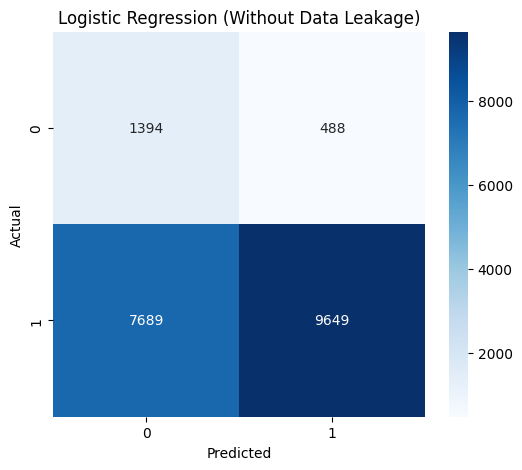

In [96]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Logistic Regression (Without Data Leakage)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [97]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [98]:
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [99]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC AUC  :", roc_auc_score(y_test, rf_prob))

Accuracy : 0.5978147762747138
Precision: 0.9492238638488872
Recall   : 0.5854769869650479
F1 Score : 0.7242437214611872
ROC AUC  : 0.696345547775558


In [100]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.16      0.71      0.26      1882
           1       0.95      0.59      0.72     17338

    accuracy                           0.60     19220
   macro avg       0.55      0.65      0.49     19220
weighted avg       0.87      0.60      0.68     19220



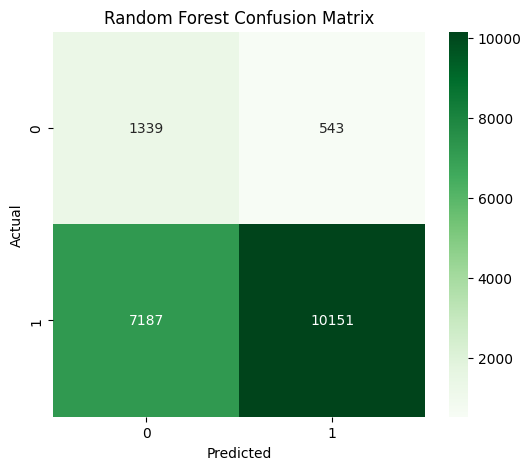

In [101]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [102]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,avg_delivery_days,0.697953
2,avg_order_value,0.113766
1,total_spent,0.112828
3,avg_review_score,0.038411
5,customer_tenure_days,0.030334
0,total_orders,0.006709


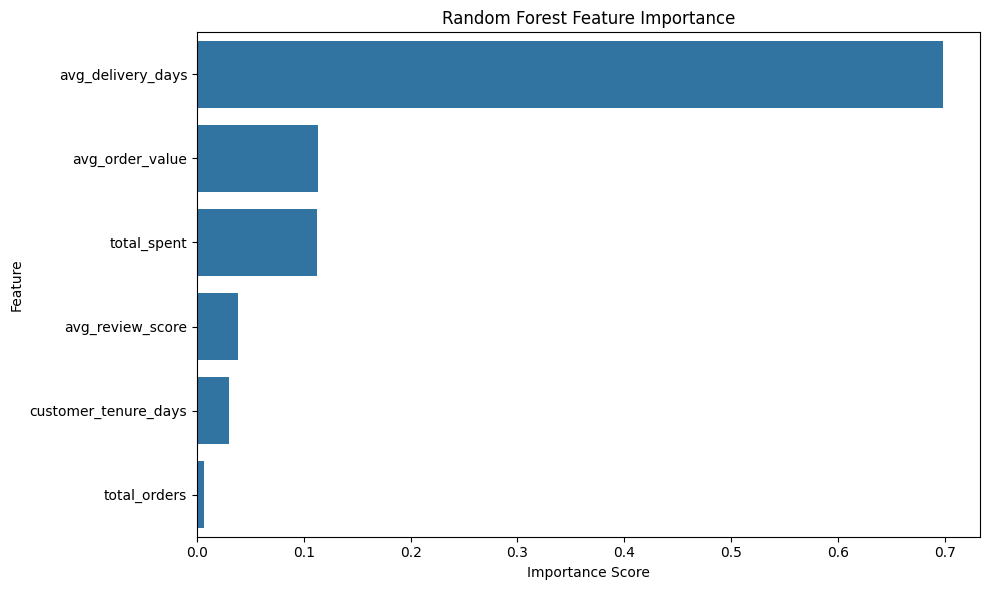

In [103]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [106]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Logistic Regression": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ],
    "Random Forest": [
        accuracy_score(y_test, rf_pred),
        precision_score(y_test, rf_pred),
        recall_score(y_test, rf_pred),
        f1_score(y_test, rf_pred),
        roc_auc_score(y_test, rf_prob)
    ]
})

comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.574558,0.597815
1,Precision,0.951860,0.949224
2,Recall,0.556523,0.585477
3,F1 Score,0.702384,0.724244
4,ROC-AUC,0.692086,0.696346


In [107]:
joblib.dump(rf_model, "../models/customer_churn_model.pkl")

['../models/customer_churn_model.pkl']

In [108]:
joblib.dump(scaler, "../models/churn_scaler.pkl")

['../models/churn_scaler.pkl']

In [109]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(rf_model, "../models/customer_churn_model.pkl")
joblib.dump(scaler, "../models/churn_scaler.pkl")

print("Models saved successfully!")

Models saved successfully!


# 📌 Project Summary – Customer Churn Prediction

## Business Problem

Customer retention is one of the most important challenges for any e-commerce business. Acquiring a new customer is often significantly more expensive than retaining an existing one. Therefore, identifying customers who are likely to stop purchasing enables businesses to proactively launch retention campaigns, personalized promotions, and customer engagement strategies.

The objective of this project was to build a machine learning model capable of predicting whether a customer is likely to churn based on their historical purchasing behavior.

---

# Dataset Overview

The analysis was performed using the customer-level dataset created from the cleaned Olist Brazilian E-commerce dataset.

Each customer was represented by aggregated behavioral features, including:

- Total number of orders
- Total spending
- Average order value
- Average review score
- Average delivery time
- Customer tenure
- Days since last purchase (initially included)

These features were engineered from transactional order-level data to create a customer-level machine learning dataset.

---

# Feature Engineering

The following customer-level features were created:

| Feature | Description |
|----------|-------------|
| total_orders | Total orders placed by the customer |
| total_spent | Total amount spent |
| avg_order_value | Average order value |
| avg_review_score | Average customer review |
| avg_delivery_days | Average delivery duration |
| customer_tenure_days | Time between first and last purchase |
| days_since_last_purchase | Days since customer's most recent purchase |

The churn label was created using the following business rule:

> Customers whose last purchase occurred more than 90 days before the latest purchase date in the dataset were labeled as churned.

---

# Data Quality Issues Encountered

During feature engineering, several missing values were identified.

| Column | Missing Values |
|----------|---------------:|
| avg_delivery_days | 2740 |
| avg_review_score | 716 |
| avg_order_value | 1 |

### Resolution

Median imputation was applied to these numerical features because:

- It is robust to outliers.
- It preserves the central tendency of the data.
- It avoids introducing unrealistic values.

After preprocessing, the dataset contained no missing values.

---

# Machine Learning Models

Two supervised classification models were trained.

### Logistic Regression

Used as the baseline classification model.

Reasons:

- Fast to train
- Highly interpretable
- Standard baseline for binary classification

---

### Random Forest

Used as an advanced ensemble model.

Reasons:

- Captures nonlinear relationships
- Handles feature interactions automatically
- Generally provides stronger predictive performance on structured business datasets

---

# Major Challenge Encountered

## Target Leakage

The initial model produced extremely high evaluation metrics.

Example:

- Accuracy ≈ 99%
- ROC-AUC ≈ 1.00

These results were unrealistic.

Investigation revealed that the feature:

```
days_since_last_purchase
```

was directly related to the target variable because churn itself had been defined using the customer's last purchase date.

As a result, the model effectively learned the rule used to create the target instead of learning meaningful customer behavior patterns.

---

# Solution

To eliminate target leakage,

```
days_since_last_purchase
```

was removed from the feature set before retraining the models.

This produced much more realistic evaluation metrics and resulted in a more trustworthy machine learning model.

---

# Model Comparison

| Metric | Logistic Regression | Random Forest |
|---------|--------------------:|--------------:|
| Accuracy | 57.46% | 59.78% |
| Precision | 95.19% | 94.92% |
| Recall | 55.65% | 58.55% |
| F1 Score | 70.24% | 72.42% |
| ROC-AUC | 0.692 | 0.696 |

Random Forest demonstrated slightly better overall performance, particularly in Recall, F1 Score, and ROC-AUC.

---

# Business Interpretation

The Random Forest model provides a practical approach for identifying customers at risk of churn.

Potential business applications include:

- Customer retention campaigns
- Personalized discount offers
- Loyalty program targeting
- Customer success prioritization
- Marketing budget optimization

Although the model does not identify every churning customer, it predicts churn with high precision, making it valuable for focused retention strategies.

---

# Final Deliverables

The following artifacts were generated:

- Customer-level feature dataset
- Churn label
- Logistic Regression model
- Random Forest model
- Model evaluation metrics
- Confusion Matrix
- Feature Importance Analysis
- Saved production-ready model (.pkl)

---

# Key Learnings

This project provided practical experience in:

- Customer-level feature engineering
- Creating target labels from transactional data
- Handling missing values
- Binary classification
- Logistic Regression
- Random Forest
- Model evaluation using Precision, Recall, F1 Score, and ROC-AUC
- Detecting and resolving target leakage
- Translating machine learning results into business recommendations

---

# Conclusion

This project demonstrates a complete end-to-end machine learning workflow, beginning with raw transactional data and ending with a deployable churn prediction model.

Beyond model development, the project emphasizes proper feature engineering, data quality management, evaluation, and business interpretation, reflecting practices commonly followed in real-world data science projects.